In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf

In [ ]:
import binvox_rw
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install keras-vis

In [ ]:
pip install tf-keras-vis tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 812.2 kB/s eta 0:00:00


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
# %matplotlib inline
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing import image
from tensorflow.keras import backend as K
from tf_keras_vis.saliency import Saliency
from tf_keras_vis.utils import normalize


import json


In [ ]:
import os
file_paths=[]
directory = '/content/drive/MyDrive/Featurenet_exp/names'

with open(os.path.join(directory, 'file_paths_train-1.txt'), 'r') as f:
    file_paths = [line.strip() for line in f]

In [ ]:
import os
labels=[]
directory = '/content/drive/MyDrive/Featurenet_exp/names'

with open(os.path.join(directory, 'labels_train_1.txt'), 'r') as f:
    labels = [int(line.strip()) for line in f]

In [ ]:
if len(labels)==len(file_paths):
  print('Go ahead things are working well')
else:
  print('check file directory')

Go ahead things are working well


In [ ]:
unique_labels=np.unique(labels)
unique_labels.shape
print(unique_labels)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [ ]:
boolean_labels =[label==unique_labels for label in labels]
print(len(boolean_labels))
boolean_labels[1396],labels[1396]

4599


(array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True, False, False,
        False, False, False, False, False, False]),
 15)

In [ ]:
NUM_IMAGES=1000 #@param {type:"slider",min:1000,max:20000}

In [ ]:
from sklearn.model_selection import train_test_split
X=file_paths
Y=boolean_labels
X_train,X_val,Y_train,Y_val=train_test_split(X[:NUM_IMAGES],Y[:NUM_IMAGES],test_size=0.1,random_state=42)

print(len(X_train),len(X_val))
print(len(Y_train),len(Y_val))

900 100
900 100


[64, 64, 64]
/content/drive/MyDrive/Featurenet_exp/all_files_ziped_64/1_491.binvox [False  True False False False False False False False False False False
 False False False False False False False False False False False False]


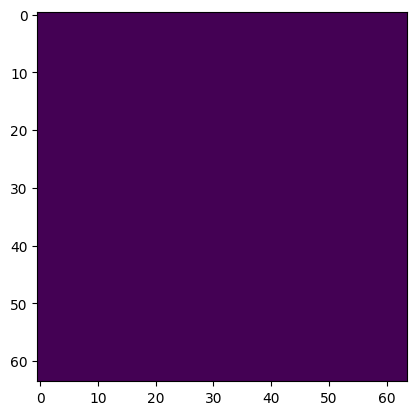

In [ ]:
'''
Viewing the binvox file in action with its corresponding label
'''
from matplotlib.pyplot import imshow
INDEX=237 #@param {type:"slider",min:0,max:2000}
file_path=X_train[INDEX]
label=Y_train[INDEX]


with open(file_path, 'rb') as fp:
       '''
       plotting the binvox file and its corresponding label
       the cross section we are taking is from the middle as a higher changes of being able to see the feature
       '''
       model = binvox_rw.read_as_3d_array(fp)
       imshow(model.data[32])
       print(model.dims)
       print(file_path,label)

In [ ]:
def process_image(path):
  if tf.is_tensor(path):
    path_str = path.numpy().decode('utf-8')
    with open (path_str,'rb') as fp:
      model=binvox_rw.read_as_3d_array(fp)
      image=model.data
      image=image.astype('float64')
      # image=tf.image.convert_image_dtype(image,tf.float32)
      # image=image+.5
      image=image-.5
      image=image*2
      image=tf.image.convert_image_dtype(image,tf.float32)
      # image=tf.constant(image)
      return image

  with open (path,'rb') as fp:
    model=binvox_rw.read_as_3d_array(fp)
    image=model.data
    image=image.astype('float64')
    # image=tf.image.convert_image_dtype(image,tf.float64)
    image=image-.5

    image=image*2
    image=tf.image.convert_image_dtype(image,tf.float64)
  return image

In [ ]:
def extract_label_image(path,label):
  if tf.is_tensor(path):
     image=tf.py_function(process_image, [path], tf.float32)
     return image,label
  else:
    image=process_image(path)
    return image,label

In [ ]:
def reshape_data_and_batch(data):
  new_images = []
  new_labels = []
  i=0
  for batch in data:
    i=i+1
    images, labels = batch  # Unpack images and labels
    # print(images.shape)


  # Assuming 'images' is a NumPy array
    reshaped_images = tf.reshape(images,[images.shape[0], images.shape[1], images.shape[2], images.shape[3], 1])  # Add channel dimension
    new_images.append(reshaped_images)
    new_labels.append(labels)

  import numpy as np
  new_images = tf.concat(new_images, axis=0)
  new_labels = tf.concat(new_labels, axis=0)
  # print(i)
  batch_size=32
  dataset = tf.data.Dataset.from_tensor_slices((new_images, new_labels)).batch(batch_size)
  return dataset

In [ ]:
BATCH_SIZE=32
'''
Process
1.print statement
2.Converting filepaths and labels a dataset of tensor
3.shuffle/noshuffle
4.extracting the labels and batching them
5.unbatching them reshaping them and then batching them

The process is unoptimized but it works
'''

def create_data_batches(X,Y,batch_size=BATCH_SIZE,valid_data=False,test_data=False):
  '''
  We are creating data batches for train,val and test sets
  We shuffle for train set only
  '''
  if test_data:
    print('Creating test data batches...')
    data=tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(Y)))

    data=data.map(extract_label_image).batch(batch_size)
    data_batch=reshape_data_and_batch(data)
    # data_batch=tf.data.Dataset.from_generator(data)
    return data_batch
  elif valid_data:
    print('Creating valid data batches...')
    data=tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(Y)))
    data=data.map(extract_label_image).batch(batch_size)
    data_batch=reshape_data_and_batch(data)
    return data_batch

  else:
    print('Creating train data batches...')
    data=tf.data.Dataset.from_tensor_slices((tf.constant(X),tf.constant(Y)))
    data=data.shuffle(buffer_size=len(X))

    data=data.map(extract_label_image).batch(batch_size)

    data_batch=reshape_data_and_batch(data)
    return data_batch

In [ ]:
val_data=create_data_batches(X_val,Y_val,valid_data=True)

Creating valid data batches...


In [ ]:
val_images,val_labels=next(val_data.as_numpy_iterator())
val_images.shape

(32, 64, 64, 64, 1)

In [ ]:
# Create a function to load a trained model
def load_model(model_path):
  """
  Loads a saved model from a specified path.
  """
  print(f"Loading saved model from: {model_path}")
  model=tf.keras.models.load_model(model_path)
  return model

In [ ]:
model=load_model("/content/drive/MyDrive/Featurenet_exp/models/20240703-140001-4500-images-train_1-24_features-featurenet-Adam.h5")

Loading saved model from: /content/drive/MyDrive/Featurenet_exp/models/20240703-140001-4500-images-train_1-24_features-featurenet-Adam.h5


In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_skf_2_7_32 (Conv3D)   (None, 32, 32, 32, 32)    11008     
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32, 32)    128       
 chNormalization)                                                
                                                                 
 conv2_skf_1_5_32 (Conv3D)   (None, 32, 32, 32, 32)    128032    
                                                                 
 conv3_skf_1_4_64 (Conv3D)   (None, 32, 32, 32, 64)    131136    
                                                                 
 conv4_skf_1_3_64 (Conv3D)   (None, 32, 32, 32, 64)    110656    
                                                                 
 max_pool_1 (MaxPooling3D)   (None, 16, 16, 16, 64)    0         
                                                      

## Viewing the voxel as images we will consider

In [ ]:
def get_truth_label_index(truth_label_bool):
  """
  Turns an array of truth labels into a label index.
  """
  label=unique_labels[np.argmax(truth_label_bool)]
  return label

get_truth_label_index(val_labels[1])

7

In [ ]:
def get_truth_label_bool_batch(prediction_label):
  """
  Turns an array of prediction probabilities into a label.
  """
  leng=len(prediction_label)
  list_of_labels=[]
  for i in range(leng):
    temp=get_truth_label_index(prediction_label[i])
    list_of_labels.append(temp)
  return list_of_labels

# get_truth_label_bool_batch(val_labels)

In [ ]:
def get_pred_label(prediction_probabilities):
  """
  Turns an array of prediction probabilities into a label.
  this also works for single boolean elements
  """
  return unique_labels[np.argmax(prediction_probabilities)]
# predictions are used after training the data
# get_pred_label(predictions[0]),predictions[0]

In [ ]:
def get_pred_label_batch(prediction_label):
  """
  Turns an array of prediction probabilities into a label.
  """
  leng=prediction_label.shape[0]
  list_of_labels=[]
  for i in range(leng):
    temp=get_pred_label(prediction_label[i])
    list_of_labels.append(temp)
  return list_of_labels

In [ ]:
import matplotlib.pyplot as plt

def show_batch_data_9(images,labels):
  plt.figure(figsize=(10,10))
  interpretable_labels=get_pred_label_batch(labels)

  for n in range(9):
    ax=plt.subplot(3,3,n+1)
    plt.imshow((images[n])[28])
    plt.title(str(interpretable_labels[n]))
    plt.axis('on')


In [ ]:
val_labels[0]

array([False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

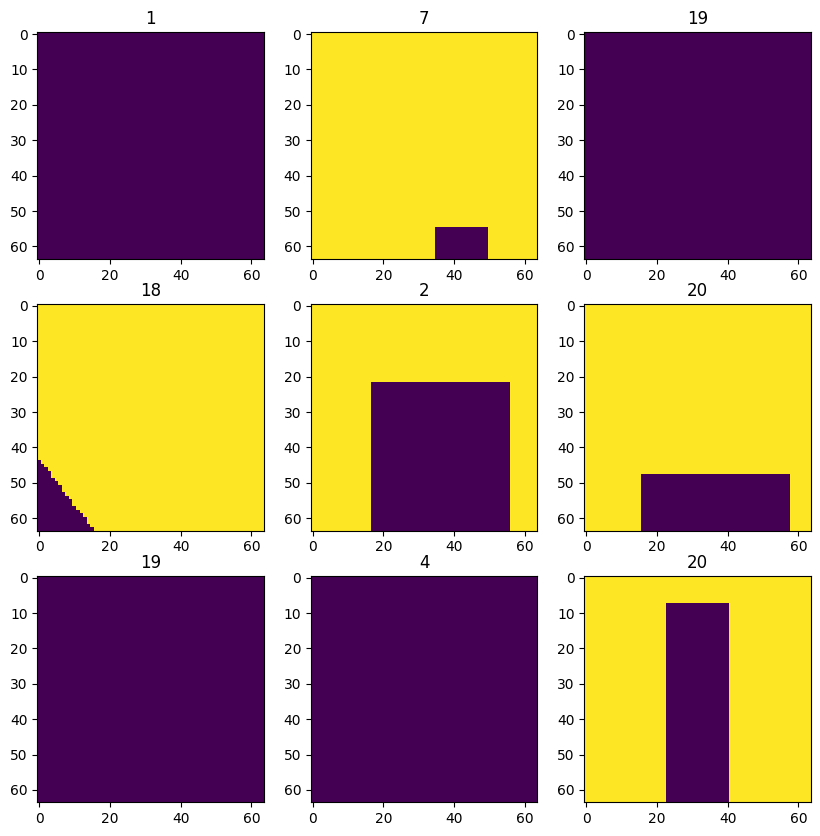

In [ ]:
val_images,val_labels=next(val_data.as_numpy_iterator())
show_batch_data_9(val_images,val_labels)

In [ ]:
val_images.shape

(32, 64, 64, 64, 1)

In [ ]:
model.evaluate(val_data)

4/4 [==============================] - 70s 16s/step - loss: 0.2441 - accuracy: 0.9300


[0.24408067762851715, 0.9300000071525574]

In [ ]:
predict_proba_check=model.predict(val_images)
# get_pred_label()
predict_proba_check.shape

1/1 [==============================] - 22s 22s/step


(32, 24)

In [ ]:
def get_pred_label_batch(prediction_probabilities):
  """
  Turns an array of prediction probabilities into a label.
  """
  len=prediction_probabilities.shape[0]
  list_of_labels=[]
  for i in range(len):
    temp=get_pred_label(prediction_probabilities[i])
    list_of_labels.append(temp)
  return list_of_labels

In [ ]:
pred_labels=get_pred_label_batch(predict_proba_check)
print(pred_labels)

[22, 7, 19, 18, 2, 20, 19, 4, 20, 13, 16, 12, 22, 16, 0, 20, 11, 8, 21, 10, 11, 9, 19, 22, 8, 20, 4, 6, 4, 2, 0, 19]


In [ ]:
import matplotlib.pyplot as plt

def show_batch_data_pred_truth(images,true_labels,predicted_probas):
  plt.figure(figsize=(10,10))
  interpretable_labels=get_truth_label_bool_batch(true_labels)
  # print(interpretable_labels)
  pred_labels=get_pred_label_batch(predicted_probas)

  for n in range(9):
    ax=plt.subplot(3,3,n+1)
    plt.imshow((images[n])[28])
    plt.title(f"true labels: {interpretable_labels[n]} predicted label :{str(pred_labels[n])}")
    plt.axis('on')


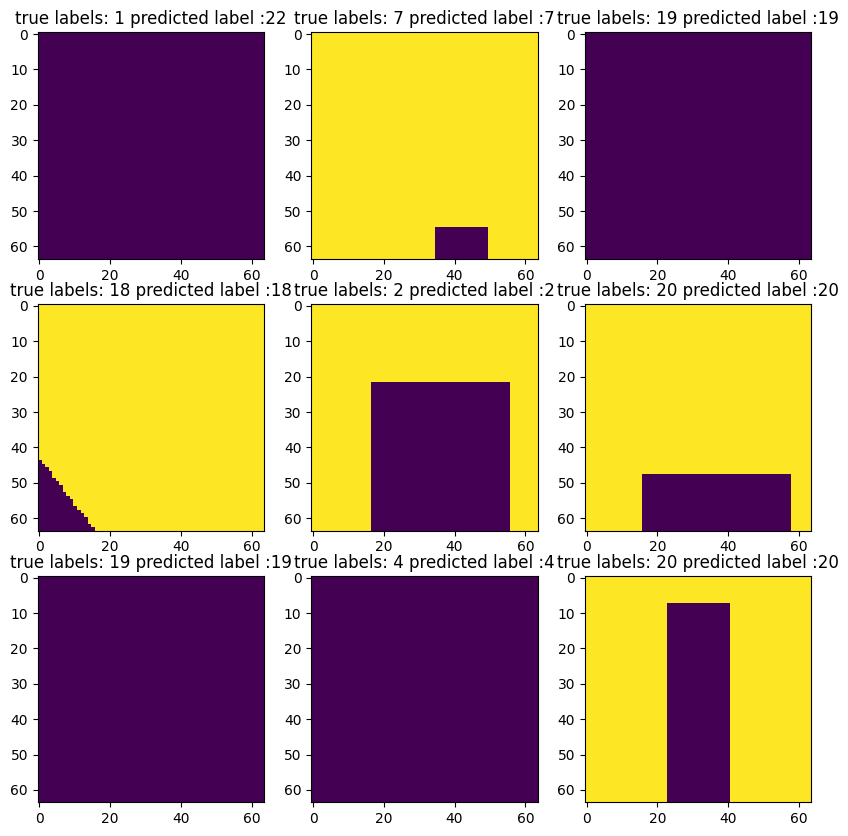

In [ ]:
val_images,val_labels=next(val_data.as_numpy_iterator())
show_batch_data_pred_truth(val_images,val_labels,predict_proba_check)

## Implementing Grad Cam

In [ ]:
model=load_model("/content/drive/MyDrive/Featurenet_exp/models/20240703-140001-4500-images-train_1-24_features-featurenet-Adam.h5")

Loading saved model from: /content/drive/MyDrive/Featurenet_exp/models/20240703-140001-4500-images-train_1-24_features-featurenet-Adam.h5


In [ ]:
# Ensure the model is not None
assert model is not None, "The model failed to load. Please check the model path and loading method."

In [ ]:
# Modify the model's output layer to have a linear activation
if model.layers[-1].activation is not tf.keras.activations.linear:
    model.layers[-1].activation = tf.keras.activations.linear
else:
    print("The output layer already has a linear activation.")

In [ ]:
assert model.layers[-1].activation == tf.keras.activations.linear, "Failed to modify the output layer's activation."

In [ ]:
# Inspect the model configuration
model_config = model.get_config()
print("Model configuration:", model_config)

# List all layer names and types
for layer in model.layers:
    print(f"Layer name: {layer.name}, Layer type: {type(layer)}")


Model configuration: {'name': 'sequential_1', 'layers': [{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_input_shape': (None, 64, 64, 64, 1), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'conv1_skf_2_7_32_input'}, 'registered_name': None}, {'module': 'keras.layers', 'class_name': 'Conv3D', 'config': {'name': 'conv1_skf_2_7_32', 'trainable': True, 'dtype': 'float32', 'filters': 32, 'kernel_size': (7, 7, 7), 'strides': (2, 2, 2), 'padding': 'same', 'data_format': 'channels_last', 'dilation_rate': (1, 1, 1), 'groups': 1, 'activation': 'relu', 'use_bias': True, 'kernel_initializer': {'module': 'keras.initializers', 'class_name': 'GlorotUniform', 'config': {'seed': None}, 'registered_name': None}, 'bias_initializer': {'module': 'keras.initializers', 'class_name': 'Zeros', 'config': {}, 'registered_name': None}, 'kernel_regularizer': None, 'bias_regularizer': None, 'activity_regularizer': None, 'kernel_constraint': None, 'bias_constraint': None}, 're

In [ ]:
# Clone the model
model_config = model.get_config()
assert model_config is not None, "The model configuration is None. Cannot clone the model."
model = tf.keras.models.clone_model(model)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense

# Load the model
model = tf.keras.models.load_model('/content/drive/MyDrive/Featurenet_exp/models/20240703-140001-4500-images-train_1-24_features-featurenet-Adam.h5')

# Check the output layer
output_layer = model.layers[-1]
print(f"Output layer before modification: {output_layer}")

# Create a new output layer with linear activation
new_output = Dense(output_layer.units, activation='linear', name='output_n')(model.layers[-2].output)

# Create a new model with the modified output layer
modified_model = Model(inputs=model.inputs, outputs=new_output)

# Verify the modification
print(f"Output layer after modification: {modified_model.layers[-1]}")


Output layer before modification: <keras.src.layers.core.dense.Dense object at 0x78bc928856f0>
Output layer after modification: <keras.src.layers.core.dense.Dense object at 0x78bc6e0cad40>


In [ ]:
modified_model.summary()


Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_skf_2_7_32_input (In  [(None, 64, 64, 64, 1)]   0         
 putLayer)                                                       
                                                                 
 conv1_skf_2_7_32 (Conv3D)   (None, 32, 32, 32, 32)    11008     
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32, 32)    128       
 chNormalization)                                                
                                                                 
 conv2_skf_1_5_32 (Conv3D)   (None, 32, 32, 32, 32)    128032    
                                                                 
 conv3_skf_1_4_64 (Conv3D)   (None, 32, 32, 32, 64)    131136    
                                                                 
 conv4_skf_1_3_64 (Conv3D)   (None, 32, 32, 32, 64)    1106

In [ ]:
import tensorflow as tf
from tensorflow.keras import models
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.gradcam import Gradcam

In [ ]:
# Define score objects for each class (0 to 23)
scores = [CategoricalScore([i]) for i in range(24)]


In [ ]:
# Create Gradcam object
gradcam = Gradcam(modified_model)

NameError: name 'cm' is not defined

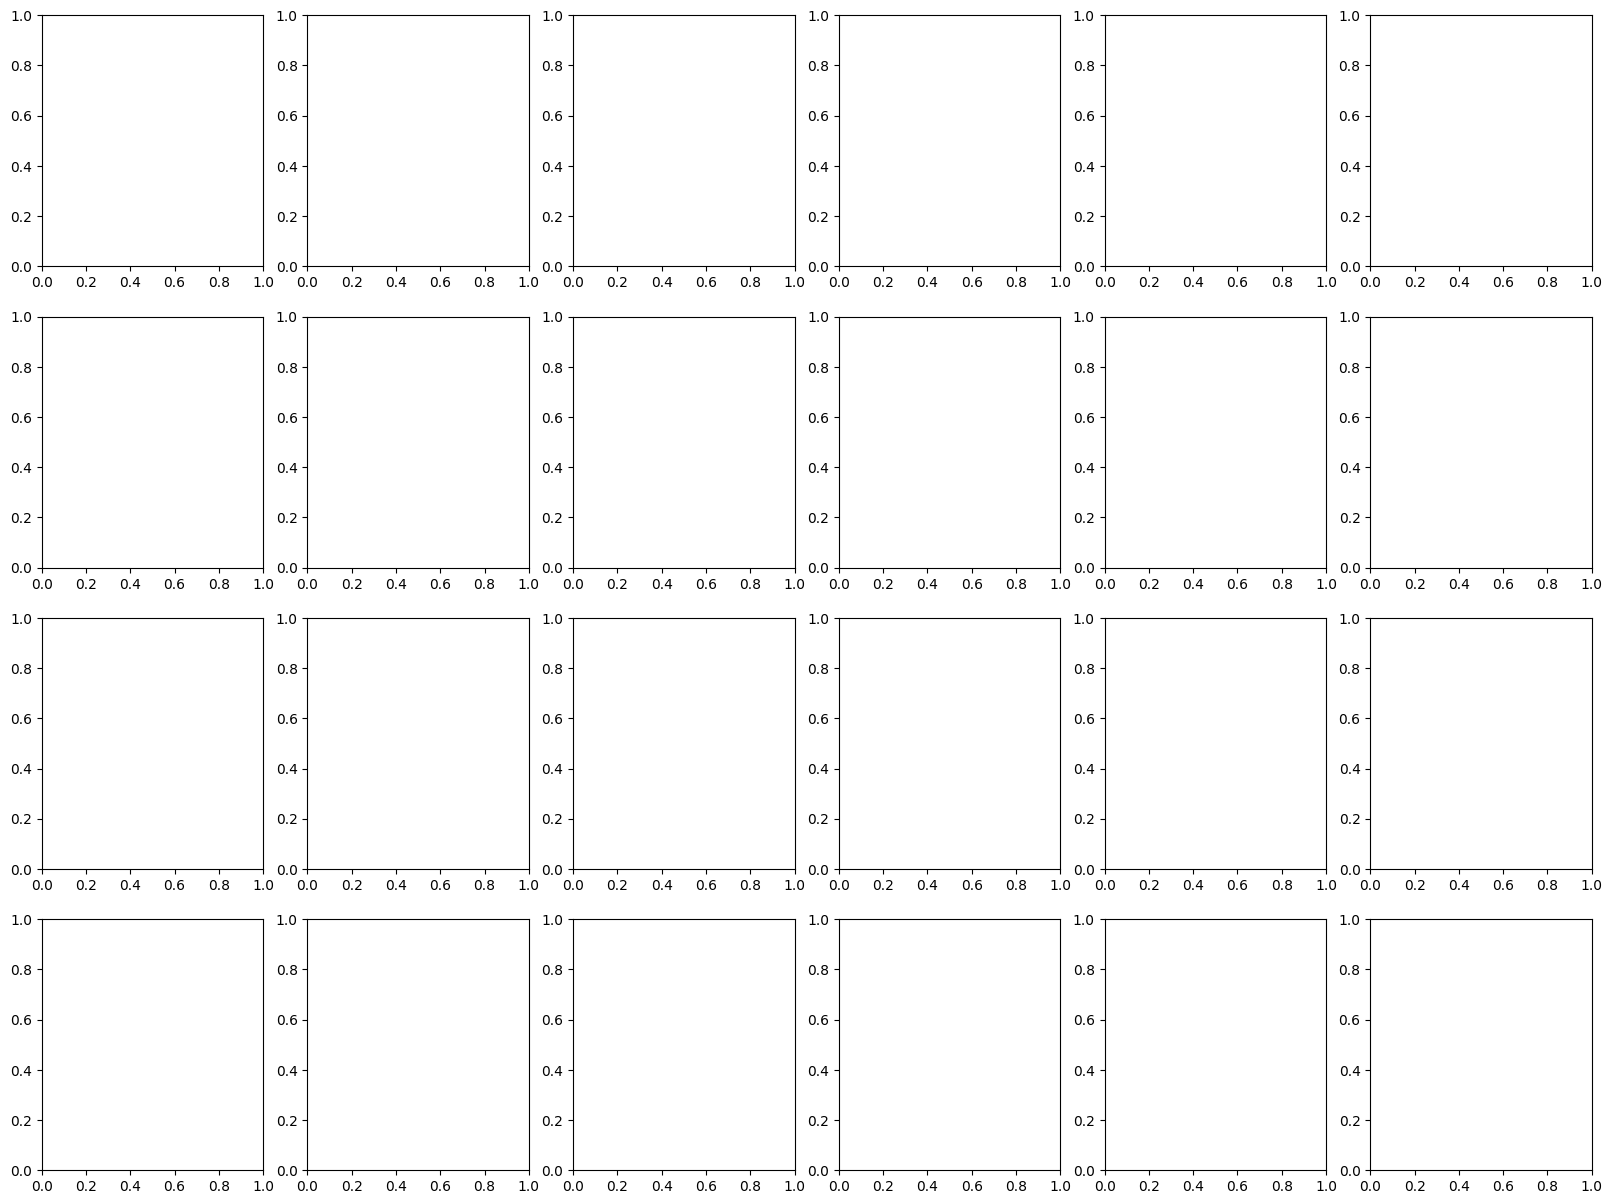

In [ ]:
# Specify the penultimate layer for GradCAM
penultimate_layer = 'conv4_skf_1_3_64'  # Name of the last conv layer

# Index of the slice you want to visualize
slice_index = 63

# Create a figure to display the images and their corresponding heatmaps
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

for i, score in enumerate(scores):
    # Generate heatmap with GradCAM for the current score
    cam = gradcam(score, val_images, penultimate_layer=penultimate_layer)

    # Plot each image and its corresponding heatmap for the specified slice
    for j in range(val_images.shape[0]):  # Iterate over batches
        ax = axes[j // 6, j % 6]  # Subplot position
        img_slice = val_images[j][slice_index, :, :]  # Specific slice of the 3D volume

        # Overlay heatmap on the original image slice
        heatmap = np.uint8(cm.jet(cam[j])[..., :3] * 255)  # Convert heatmap to RGB
        ax.imshow(img_slice, cmap='gray')  # Plot the grayscale image slice
        ax.imshow(heatmap[slice_index], cmap='jet', alpha=0.5)  # Overlay the heatmap
        ax.set_title(f"Class {i}, Slice {slice_index}")  # Set subplot title
        ax.axis('off')  # Turn off axis

plt.tight_layout()  # Adjust layout
plt.show()  # Display plot



In [ ]:
scores[7]

In [ ]:
import matplotlib.pyplot as plt

def show_batch_data_pred_truth(images,true_labels,predicted_probas):
  plt.figure(figsize=(20,20))
  interpretable_labels=get_truth_label_bool_batch(true_labels)
  # print(interpretable_labels)
  pred_labels=get_pred_label_batch(predicted_probas)

  for n in range(9):
    ax=plt.subplot(3,3,n+1)
    plt.imshow((images[n])[63])
    plt.title(f"true labels: {interpretable_labels[n]} predicted label :{str(pred_labels[n])}")
    plt.axis('on')


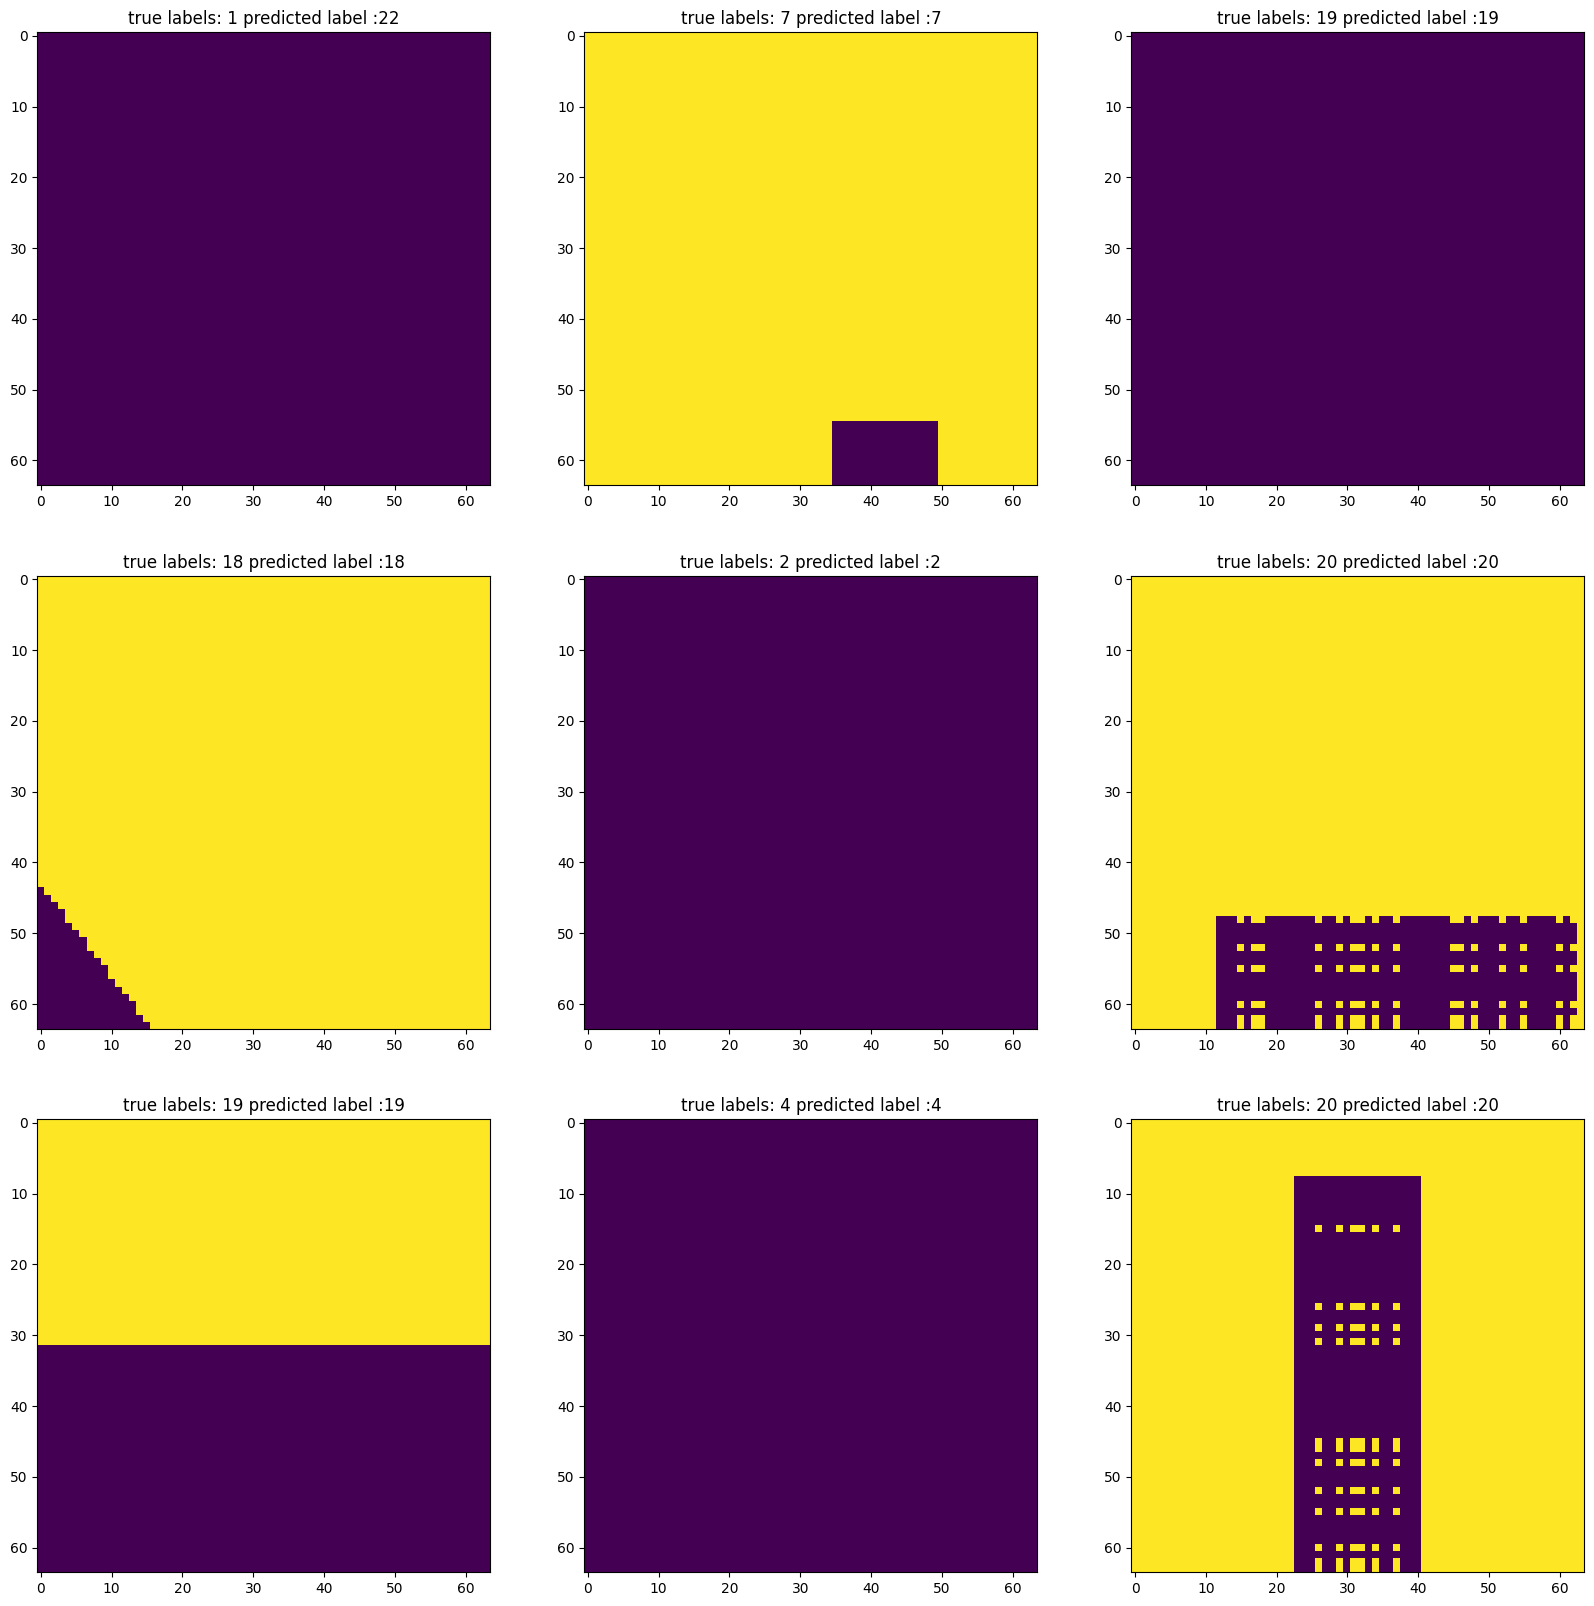

In [ ]:
show_batch_data_pred_truth(val_images,val_labels,predict_proba_check)


In [ ]:
penultimate_layer = 'conv4_skf_1_3_64'


# Create a figure to display the images and their corresponding heatmaps
score=scores[8]
cam = gradcam(score, val_images, penultimate_layer=penultimate_layer)



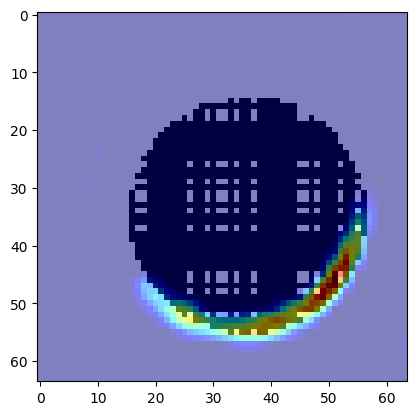

In [ ]:
slice_index = 63
index_batch=4
img_slice = val_images[index_batch][:,slice_index, :]  # Specific slice of the 3D volume

heatmap = np.uint8(cm.jet(cam[index_batch])[..., :3] * 255)
imshow(img_slice, cmap='gray')
imshow(heatmap[:,slice_index], cmap='jet', alpha=0.5)

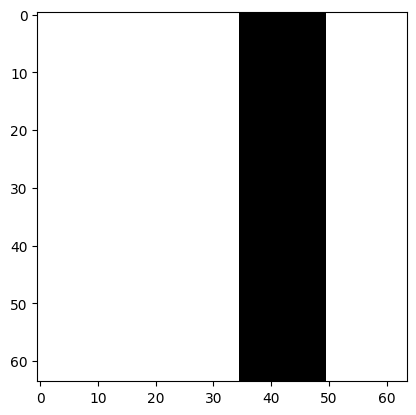

In [ ]:
imshow(img_slice, cmap='gray')


In [ ]:
# ax = axes[j // 6, j % 6]  # Subplot position


In [ ]:
# Check the model configuration
model_config = model.get_config()
assert model_config is not None, "The model configuration is None. Cannot clone the model."
print("Model configuration retrieved successfully.")

Model configuration retrieved successfully.


In [ ]:
try:
    cloned_model = tf.keras.models.clone_model(model)
    print("Model cloned successfully without modifications.")
except Exception as e:
    print(f"Failed to clone model without modifications: {e}")

Model cloned successfully without modifications.


In [ ]:
# Modify the model's output layer to have a linear activation
if model.layers[-1].activation is not tf.keras.activations.linear:
    model.layers[-1].activation = tf.keras.activations.linear
else:
    print("The output layer already has a linear activation.")

# Ensure the modification is successful
assert model.layers[-1].activation == tf.keras.activations.linear, "Failed to modify the output layer's activation."

# Clone the model after modifying the output layer
try:
    modified_model = tf.keras.models.clone_model(model)
    print("Model cloned successfully after modifying the output layer.")
except Exception as e:
    print(f"Failed to clone model after modifying the output layer: {e}")

# Apply the model modifier
try:
    model_modifier = ReplaceToLinear()
    modified_model = model_modifier(modified_model)
    assert modified_model is not None, "Model modification failed. Check the model structure and configuration."
    print("Model modification applied successfully.")
except Exception as e:
    print(f"Failed to apply model modification: {e}")


The output layer already has a linear activation.
Model cloned successfully after modifying the output layer.
Failed to apply model modification: Model modification failed. Check the model structure and configuration.


In [ ]:
# from matplotlib import cm
# from tf_keras_vis.gradcam import Gradcam
# from tf_keras_vis.utils.scores import CategoricalScore
# interpretable_labels=get_truth_label_bool_batch(val_labels)
# score = CategoricalScore(interpretable_labels)
# input_classes=interpretable_labels
# input_images =val_images

# gradcam=Gradcam(model,clone=True)

# cam=gradcam(score,input_images,penultimate_layer=-1)

# f, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 4))
# for i, img_class in enumerate(input_classes):
#     heatmap = np.uint8(cm.jet(cam[i])[..., :4] * 255)
#     ax[i].set_title(img_class, fontsize=16)
#     ax[i].imshow(val_images[i][28,:,:0:2])
#     ax[i].imshow(heatmap, cmap='jet', alpha=0.5) # overlay
#     ax[i].axis('off')
# plt.tight_layout()
# plt.show()

In [ ]:
unique_labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [ ]:
import tensorflow as tf
from tensorflow.keras import models
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.gradcam import Gradcam

In [ ]:
model.layers[-1].activation = tf.keras.activations.linear
model = models.clone_model(model)

In [ ]:
model_modifier = ReplaceToLinear()
model = model_modifier(model)

In [ ]:
from tf_keras_vis.utils.scores import CategoricalScore

# Define the score object to specify which class activations to visualize
# For 24 classes, create a list of scores for all class indices from 0 to 23
scores = [CategoricalScore([i]) for i in range(24)]

In [ ]:
from tf_keras_vis.gradcam import Gradcam
import matplotlib.pyplot as plt
from matplotlib import cm
import tensorflow as tf
from tensorflow.keras import models
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.gradcam import Gradcam
import matplotlib.pyplot as plt
from matplotlib import cm

# Create Gradcam object
gradcam = Gradcam(model, model_modifier=model_modifier, clone=True)

# Generate heatmap with GradCAM
# The `penultimate_layer` should be the index of the last convolutional layer
penultimate_layer = -1  # Typically the last conv layer, adjust if necessary

# Create a figure to display the images and their corresponding heatmaps
fig, axes = plt.subplots(nrows=4, ncols=6, figsize=(20, 15))

for i, score in enumerate(scores):
    cam = gradcam(score, preprocessed_images, penultimate_layer=penultimate_layer)

    for j in range(preprocessed_images.shape[0]):
        ax = axes[i // 6, i % 6]
        img = val_images[j]
        heatmap = np.uint8(cm.jet(cam[j])[..., :4] * 255)

        ax.set_title(f"Class {i} - Image {j+1}")
        ax.imshow(np.max(img, axis=-1), cmap='gray')  # Displaying max projection for visualization
        ax.imshow(np.max(heatmap, axis=-1), cmap='jet', alpha=0.5)  # Overlay the heatmap
        ax.axis('off')

plt.tight_layout()
plt.show()


AttributeError: type object 'NoneType' has no attribute 'from_config'

## One Voxel and Its Output Analysis

2


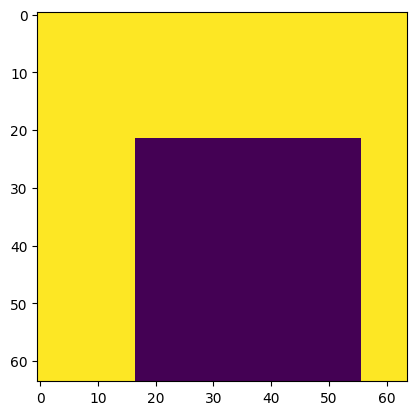

In [ ]:
import matplotlib.pyplot as plt

index=4
print(np.argmax(val_labels[index]))
plt.imshow(val_images[index][28])

truth label :2


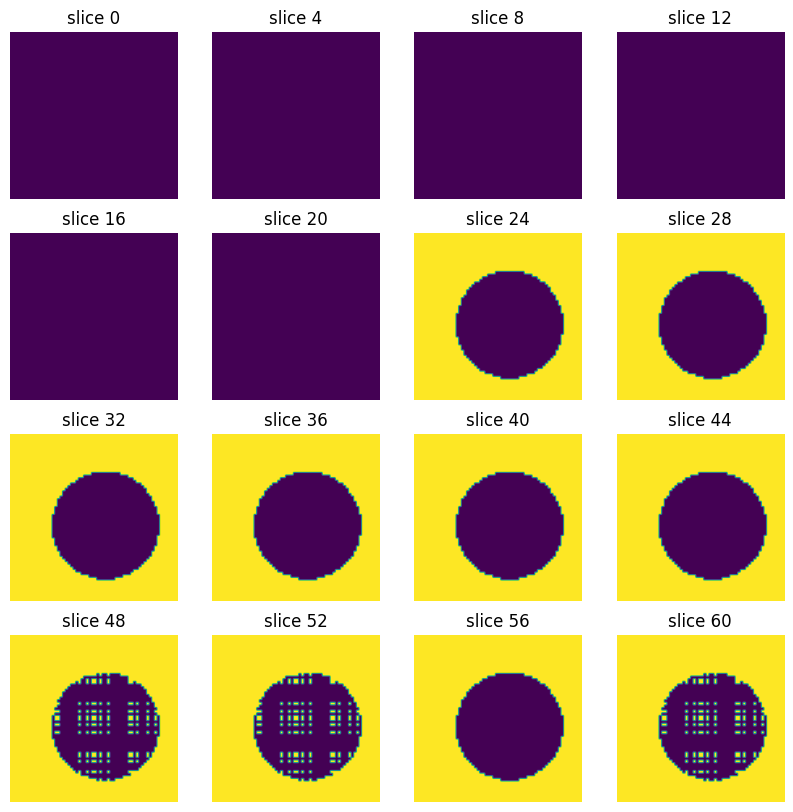

In [ ]:
'''
Plotting multiple slices of the above 3d Voxel
using Matplot libs plt function
here we are taking in only one direction for ex. x axis
'''
fig ,axs=plt.subplots(4,4,figsize=(10,10))
temp_x=0
temp_y=0
print(f"truth label :{np.argmax(val_labels[index])}")
for i in range (4):
  # slice=i*4
  for j in range(4):
    slice=(temp_x+temp_y)*4
    axs[i,j].imshow(val_images[index][:,slice])
    axs[i,j].axis('off')
    axs[i,j].set_title(f"slice {slice}")
    if(j<3):
      temp_y=temp_y+1
  # temp_y=temp_y+1
  temp_x=temp_x+1

In [ ]:
layer_names = [layer.name for layer in model.layers]
print(layer_names)

['conv1_skf_2_7_32', 'batch_normalization_1', 'conv2_skf_1_5_32', 'conv3_skf_1_4_64', 'conv4_skf_1_3_64', 'max_pool_1', 'flatten_1', 'dense_1', 'output_n']


In [ ]:
last_conv_layer_name = 'conv4_skf_1_3_64'

In [ ]:
import os
import random



import cv2
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import tensorflow as tf
from ipywidgets import IntSlider, interact
from matplotlib import animation, rc
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
from scipy import ndimage
from scipy.ndimage import zoom
from tensorflow.keras import Input, Model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay

In [ ]:
'''
Building Grad_model that takes in model inputs and outputs values in convulational layer and the final softmax
Our model has 34 Million parameters
'''
grad_model = Model(
        [model.inputs], [model.get_layer(
            last_conv_layer_name).output, model.output]
    )
grad_model.summary()

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1_skf_2_7_32_input (In  [(None, 64, 64, 64, 1)]   0         
 putLayer)                                                       
                                                                 
 conv1_skf_2_7_32 (Conv3D)   (None, 32, 32, 32, 32)    11008     
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32, 32)    128       
 chNormalization)                                                
                                                                 
 conv2_skf_1_5_32 (Conv3D)   (None, 32, 32, 32, 32)    128032    
                                                                 
 conv3_skf_1_4_64 (Conv3D)   (None, 32, 32, 32, 64)    131136    
                                                                 
 conv4_skf_1_3_64 (Conv3D)   (None, 32, 32, 32, 64)    1106

In [ ]:
preds=model.predict(val_images)

1/1 [==============================] - 29s 29s/step


In [ ]:
temp_index=14
np.argmax(preds[temp_index]),np.argmax(val_labels[temp_index]),np.max(preds[temp_index])

(0, 0, 0.9997902)

In [ ]:
'''
pred_index is the class im trying to generate the heatmap
class channel is the probablity or score for a class pred_index which is the image we are using and storing the probablities for all the images in the batch
'''
pred_index=None
with tf.GradientTape() as tape:
  last_conv_layer_output, preds = grad_model(val_images)
  if pred_index is None:
    # pred_index = np.argmax(preds[index])
    pred_index = tf.argmax(preds[index])
  class_channel = preds[:,pred_index]

In [ ]:
'''
So its considering probabilities for only the given index for all the images in the batch
'''
class_channel.numpy()

array([2.2379952e-06, 4.1032269e-10, 1.7599601e-07, 2.3585003e-10,
       4.6378349e-07, 4.5522718e-12, 2.1250859e-10, 1.0221734e-14,
       7.2313455e-06, 2.9012270e-11, 2.7656879e-09, 3.1348063e-10,
       6.8839764e-13, 9.6550754e-12, 9.9979019e-01, 2.1771976e-17,
       1.3000395e-08, 2.1784307e-04, 5.3299070e-15, 2.0242212e-06,
       5.2312715e-10, 2.0385084e-04, 7.8122781e-07, 8.0820701e-06,
       5.7432258e-05, 6.3913018e-07, 6.7112683e-11, 4.3087494e-09,
       1.2784105e-07, 1.8039873e-05, 9.9999994e-01, 2.5277639e-11],
      dtype=float32)

In [ ]:
np.max(preds[2])

0.90586406

In [ ]:
'''
what does our last conv layer output look like
we can infer there is high spatial pixels varying from 0 to as 60 as avlue as well
'''
print(f" number of unique values: {len(np.unique(last_conv_layer_output))}  what were the unique values: {np.unique(last_conv_layer_output)}")
print(last_conv_layer_output.shape)

 number of unique values: 5271  what were the unique values: [0.0000000e+00 7.8600412e-04 1.1290214e-03 ... 5.2242928e+01 5.2275852e+01
 6.0289944e+01]
(32, 32, 32, 32, 64)


In [ ]:
grads = tape.gradient(class_channel, last_conv_layer_output)

In [ ]:
'''
Gradients are stored as tensors
'''
print(f" number of unique values: {len(np.unique(grads.numpy()))}  what were the unique values: {np.unique(grads.numpy())}")
print(grads.numpy().shape)

 number of unique values: 8313471  what were the unique values: [-5.0987484e-05 -4.4748926e-05 -4.3126984e-05 ...  6.2073763e-05
  6.2604035e-05  7.8335281e-05]
(32, 32, 32, 32, 64)


In [ ]:
'''
Vanishing Gradients concept , why is it so small ?
'''
print(f"maximum of the gradients: {np.max(grads.numpy())}")

maximum of the gradients: 7.833528070477769e-05


In [ ]:
'''
Getting the mean of all the gradients equivalent to global average pooling
each value of pooled grad is multiplied with one feature map
'''
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

In [ ]:
print(f" number of unique values: {len(np.unique(pooled_grads.numpy()))}  what were the unique values: {np.unique(pooled_grads.numpy())}")
print(pooled_grads.numpy().shape)

 number of unique values: 64  what were the unique values: [9.55809742e-09 1.27800330e-08 1.44430512e-08 1.82509829e-08
 3.06031680e-08 3.31105809e-08 3.55026941e-08 4.30124700e-08
 4.37390923e-08 4.41469652e-08 4.76713886e-08 5.35491615e-08
 6.04114305e-08 6.85000856e-08 7.33344194e-08 7.71256836e-08
 8.03255062e-08 8.09554308e-08 8.79633077e-08 9.41754266e-08
 9.53619406e-08 9.54373363e-08 9.56883639e-08 9.60617967e-08
 9.70887157e-08 1.00723796e-07 1.07498963e-07 1.08169154e-07
 1.08531943e-07 1.10161828e-07 1.19700658e-07 1.19892832e-07
 1.23839172e-07 1.24222751e-07 1.32347992e-07 1.32813980e-07
 1.38183566e-07 1.41879767e-07 1.43114235e-07 1.43879774e-07
 1.45089828e-07 1.45666306e-07 1.46728780e-07 1.46863187e-07
 1.48650173e-07 1.49635511e-07 1.52764670e-07 1.56599782e-07
 1.57800727e-07 1.62513132e-07 1.64961847e-07 1.68345011e-07
 1.77038046e-07 1.79313616e-07 1.80252627e-07 1.81025712e-07
 1.81931455e-07 1.83779932e-07 1.84331896e-07 1.87391919e-07
 1.89532273e-07 1.95747432

In [ ]:
class_channel.numpy()

array([2.2379952e-06, 4.1032269e-10, 1.7599601e-07, 2.3585003e-10,
       4.6378349e-07, 4.5522718e-12, 2.1250859e-10, 1.0221734e-14,
       7.2313455e-06, 2.9012270e-11, 2.7656879e-09, 3.1348063e-10,
       6.8839764e-13, 9.6550754e-12, 9.9979019e-01, 2.1771976e-17,
       1.3000395e-08, 2.1784307e-04, 5.3299070e-15, 2.0242212e-06,
       5.2312715e-10, 2.0385084e-04, 7.8122781e-07, 8.0820701e-06,
       5.7432258e-05, 6.3913018e-07, 6.7112683e-11, 4.3087494e-09,
       1.2784105e-07, 1.8039873e-05, 9.9999994e-01, 2.5277639e-11],
      dtype=float32)

In [ ]:
last_conv_layer_output_index=last_conv_layer_output[index]
last_conv_layer_output_index.shape

TensorShape([32, 32, 32, 64])

In [ ]:
heatmap = last_conv_layer_output_index @ pooled_grads[..., tf.newaxis]

In [ ]:
heatmap = tf.squeeze(heatmap)

In [ ]:
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

In [ ]:
heatmap.numpy().shape

(32, 32, 32)

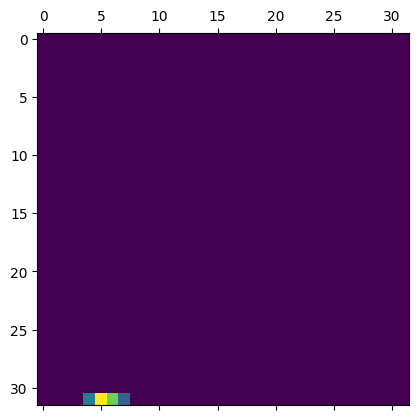

In [ ]:
plt.matshow((heatmap[12, :, :]))
plt.show()

In [ ]:
'''
A function which generates a heat map
1. creates a model with outputs of last conv layer and the final output probablities
2. using tape.gradient for autodiff and storing class channels: probability of the index class for all the images
3.Then we find gradients for all the images in the batch for that particular class
4. then we pool the gradients occuring from the whole batch
5. Now we have $\alpha$ for each feature map in that layer when we would calculate for the image
6. Then we multiply feature map and grads to heatmap
'''

def make_gradcam_heatmap(img_arrays, model, last_conv_layer_name,image_index=0,pred_index=None):
    """Generate class activation heatmap"""
    # First, we create a model that maps the input image to the activations
    # of the last conv layer as well as the output predictions
    grad_model = Model(
        [model.inputs], [model.get_layer(
            last_conv_layer_name).output, model.output]
    )

    # Then, we compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last conv layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_arrays)
        if pred_index is None:
            pred_index = tf.argmax(preds[image_index])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen)
    # with regard to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient
    # over a specific feature map channel (equivalent to global average pooling)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2, 3))

    # We multiply each channel in the feature map array
    # by 'how important this channel is' with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[image_index]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, we will also normalize the heatmap between 0 & 1
    # Notice that we clip the heatmap values, which is equivalent to applying ReLU
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

In [ ]:
preds = model.predict(val_images)
print('Predicted:',np.argmax( preds[index]))

1/1 [==============================] - 28s 28s/step
Predicted: 2


In [ ]:
val_images[14].shape

(64, 64, 64, 1)

In [ ]:
val_image_index=val_images[index]
val_image_index=np.expand_dims(val_image_index,axis=0)
val_image_index.shape

(1, 64, 64, 64, 1)

In [ ]:
heatmap = make_gradcam_heatmap(val_images, model, last_conv_layer_name,image_index=index)

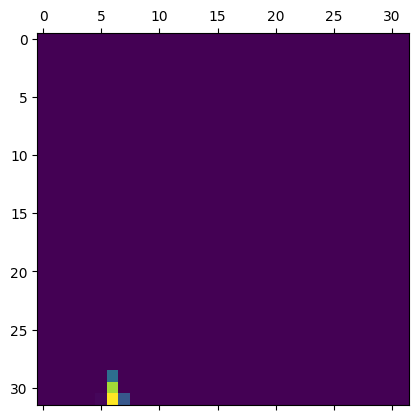

In [ ]:
plt.matshow(np.squeeze(heatmap[12, :, :]))
plt.show()

In [ ]:
def get_resized_heatmap(heatmap, shape):
    """Resize heatmap to shape"""
    # Rescale heatmap to a range 0-255
    upscaled_heatmap = np.uint8(255 * heatmap)

    upscaled_heatmap = zoom(
        upscaled_heatmap,
        (
            shape[0] / upscaled_heatmap.shape[0],
            shape[1] / upscaled_heatmap.shape[1],
            shape[2] / upscaled_heatmap.shape[2],
        ),
    )

    return upscaled_heatmap


(1, 64, 64, 64, 1)

In [ ]:
shape=[64,64,64]
resized_heatmap = get_resized_heatmap(heatmap, shape)

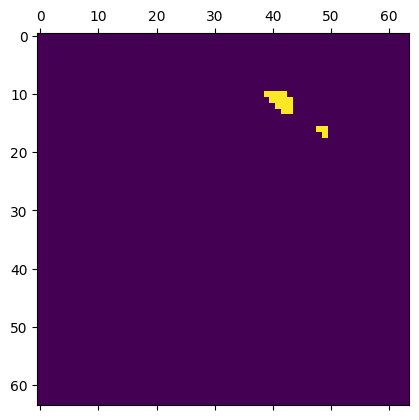

In [ ]:
plt.matshow(np.squeeze(resized_heatmap[:, 28, :]))
plt.show()

In [ ]:
resized_heatmap.shape

(64, 64, 64)

truth label :2


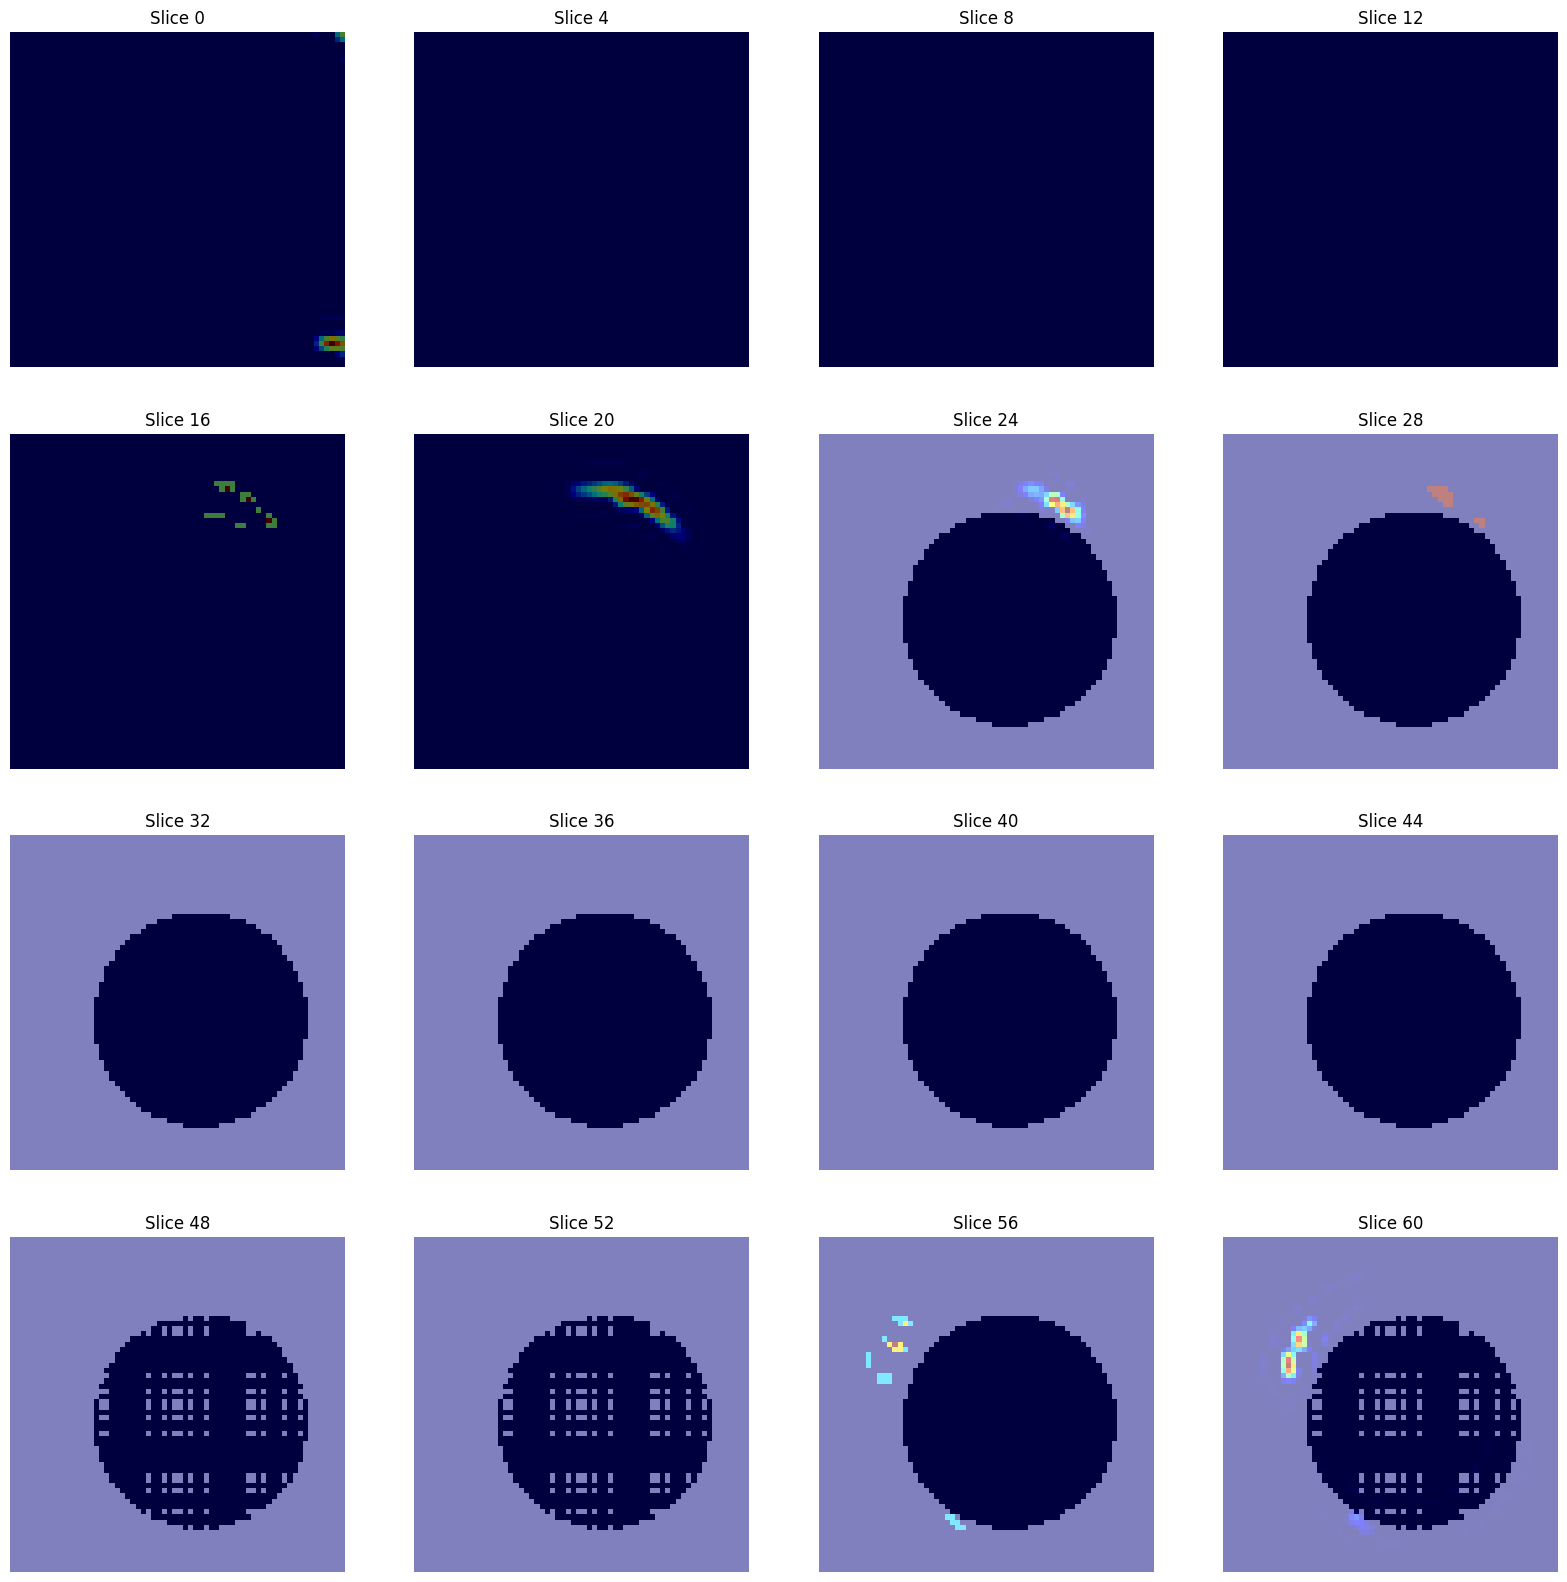

In [ ]:
fig ,axs=plt.subplots(4,4,figsize=(20,20))
temp_x=0
temp_y=0
print(f"truth label :{np.argmax(val_labels[index])}")
for i in range (4):
  # slice=i*4
  for j in range(4):
    slice=(temp_x+temp_y)*4
    image = val_images[index][:,slice,:]
    heatmap = resized_heatmap[:,slice,:]

    # Plot the image
    axs[i, j].imshow(image.squeeze(), cmap='gray')
    axs[i, j].axis('off')
    axs[i, j].set_title(f"Slice {slice}")

    # Overlay the heatmap with transparency
    axs[i, j].imshow(heatmap, alpha=0.5, cmap='jet')
    if(j<3):
      temp_y=temp_y+1
  # temp_y=temp_y+1
  temp_x=temp_x+1

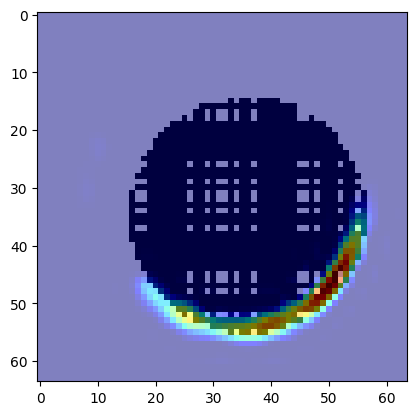

In [ ]:

image = val_images[index][:,63,:]
heatmap = resized_heatmap[:,63,:]

    # Plot the image
plt.imshow(image.squeeze(), cmap='gray')
    # Overlay the heatmap with transparency
plt.imshow(heatmap, alpha=0.5, cmap='jet')